In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00
Model                | MAE (ft)   | RMSE (ft)  | R2 Score  
------------------------------------------------------------
Random Forest        | 10.69      | 14.86      | 0.6233    
XGBoost              | 9.76       | 13.16      | 0.7046    


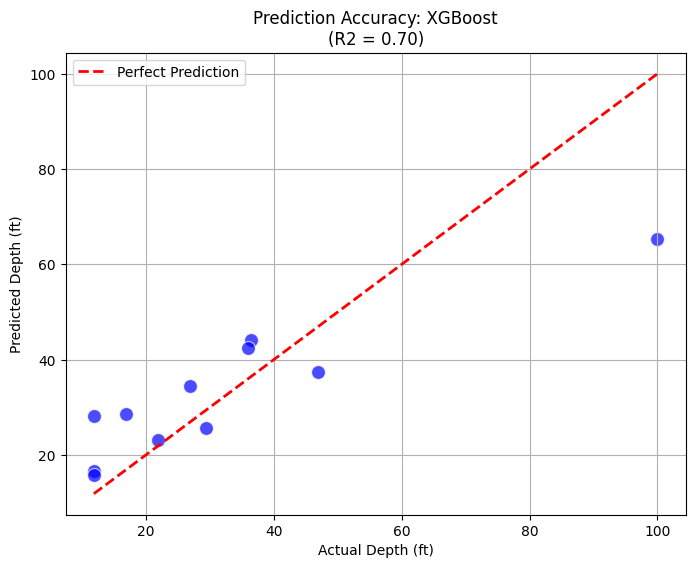

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    cross_val_predict
)

# Imbalance / preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Models
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor
)
from xgboost import XGBRegressor
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 1. LOAD DATA
df = pd.read_excel('/content/drive/MyDrive/IE6318/Project_Files/Prediction_Dataset.xlsx', header=1)

# 2. DEFINE TARGET AND FEATURES
target_col = 'Pier total Depth (ft)'

# Drop identification columns that don't help prediction
cols_to_drop = ['SI', 'Asset Name', 'NBI 007: Facility Carried by Structure', 'NBI 006: Feature Intersected']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Define Feature Groups
numeric_features = [
    'Avg Daily Trafic', 'Regulatory Speed (mph)', 'Scour rating 113',
    'No of Lanes', 'Total Length (ft)', 'Total Number of Spans',
    'Max Span Length (ft)', 'Min Span Length (ft)', 'Deck Width (ft)',
    'Roadway Width (ft)', 'Skew', 'Girder spacing (ft)',
    'Bent Cap depth (ft)', 'Bent Cap width (ft)',
    'No of drilled shaft per bent', 'Pier size/dia (in)',
    'Embedded Pier size/dia (in)', 'Pier Spacing (ft)',
    'Pier unbraced length (ft)'
]

categorical_features = ['Design Load', 'Girder Type', 'Rail Type', 'Pier Shape']

# 3. DATA CLEANING (The "U" Problem)
# Convert columns meant to be numeric but containing 'U' or text
for col in numeric_features:
    # Force convert to numeric, turning 'U' and errors into NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert categorical features to string type to avoid mixed-type issues with OneHotEncoder
for col in categorical_features:
    df[col] = df[col].astype(str)

# Create Bridge Age
df['Bridge_Age'] = 2025 - pd.to_numeric(df['Years Build'], errors='coerce')
numeric_features.append('Bridge_Age')

# Define X (Features) and y (Target)
X = df[numeric_features + categorical_features]
y = df[target_col]

# 4. PREPROCESSING PIPELINE
# Numeric: Impute missing with Median -> Scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Impute missing -> OneHotEncode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. TRAIN REGRESSION MODELS
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Models
regressors = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

print(f"{'Model':<20} | {'MAE (ft)':<10} | {'RMSE (ft)':<10} | {'R2 Score':<10}")
print("-" * 60)

results = {}

for name, model in regressors.items():
    # Create pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Train
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Calculate Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'y_test': y_test, 'y_pred': y_pred, 'r2': r2}

    print(f"{name:<20} | {mae:<10.2f} | {rmse:<10.2f} | {r2:<10.4f}")

# 6. VISUALIZE PREDICTIONS (Best Model)
# Determine best model by R2
best_model_name = max(results, key=lambda k: results[k]['r2'])
best_data = results[best_model_name]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=best_data['y_test'], y=best_data['y_pred'], color='blue', s=100, alpha=0.7)
# Plot the perfect prediction line
min_val = min(best_data['y_test'].min(), best_data['y_pred'].min())
max_val = max(best_data['y_test'].max(), best_data['y_pred'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Depth (ft)')
plt.ylabel('Predicted Depth (ft)')
plt.title(f'Prediction Accuracy: {best_model_name}\n(R2 = {best_data["r2"]:.2f})')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# Drop identification columns that are not useful for prediction
cols_to_drop = [
    'SI', 'Asset Name',
    'NBI 007: Facility Carried by Structure',
    'NBI 006: Feature Intersected'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

# List of Numeric Features (Inputs)
numeric_features = [
    'Avg Daily Trafic', 'Regulatory Speed (mph)', 'Scour rating 113',
    'No of Lanes', 'Total Length (ft)', 'Total Number of Spans',
    'Max Span Length (ft)', 'Min Span Length (ft)', 'Deck Width (ft)',
    'Roadway Width (ft)', 'Skew', 'Girder spacing (ft)',
    'Bent Cap depth (ft)', 'Bent Cap width (ft)',
    'No of drilled shaft per bent', 'Pier size/dia (in)',
    'Embedded Pier size/dia (in)', 'Pier Spacing (ft)',
    'Pier unbraced length (ft)'
]

# List of Categorical Features (Inputs)
categorical_features = ['Design Load', 'Girder Type', 'Rail Type', 'Pier Shape']

# 3. DATA CLEANING (Handling 'U' and Errors)
# Loop through numeric columns to replace 'U' with NaN and convert text to numbers
for col in numeric_features:
    # Force convert to numeric; errors='coerce' turns "U" and text into NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert categorical features to string type to avoid mixed-type issues with OneHotEncoder
for col in categorical_features:
    df[col] = df[col].astype(str)

# 4. FEATURE ENGINEERING
# Create 'Bridge_Age' (Current Year - Year Built)
# We use 2025 as the current reference year
df['Bridge_Age'] = 2025 - pd.to_numeric(df['Years Build'], errors='coerce')

# Add the new feature to our numeric list
numeric_features.append('Bridge_Age')

# 5. SEPARATE INPUTS (X) AND TARGET (y)
X = df[numeric_features + categorical_features]
y = df[target_col]

# 6. BUILD THE PREPROCESSING PIPELINE
# Step A: Numeric Data -> Fill Missing (Median) -> Scale (Z-Score)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Step B: Categorical Data -> Fill Missing (Most Frequent) -> Encode (One-Hot)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Step C: Combine both into one processor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False # Keeps column names clean
)

# 7. APPLY TRANSFORMATION
# This returns a cleaned, scaled, and encoded NumPy array
X_processed = preprocessor.fit_transform(X)

# OPTIONAL: Convert back to DataFrame to verify visually
feature_names = numeric_features + list(preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features))
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print("--- Data Preprocessing Complete ---")
print(f"Original Data Shape: {df.shape}")
print(f"Processed Data Shape: {X_processed_df.shape}")
print("\nFirst 5 rows of processed data:")
print(X_processed_df.head())

--- Data Preprocessing Complete ---
Original Data Shape: (55, 27)
Processed Data Shape: (55, 54)

First 5 rows of processed data:
   Avg Daily Trafic  Regulatory Speed (mph)  Scour rating 113  No of Lanes  \
0          1.839980                0.088093         -1.000860     0.716147   
1          1.351429                1.703122          0.897323    -0.442326   
2         -1.015746               -0.315665          0.897323    -0.442326   
3         -0.978800               -0.719422         -1.000860    -0.442326   
4         -0.112161                0.491850          0.897323    -0.442326   

   Total Length (ft)  Total Number of Spans  Max Span Length (ft)  \
0          -0.275476               0.120784             -0.890561   
1           1.041045               1.026667              0.825433   
2          -0.507474              -0.785098             -0.630562   
3          -0.423619               0.120784             -1.284274   
4          -0.149694              -0.483137             

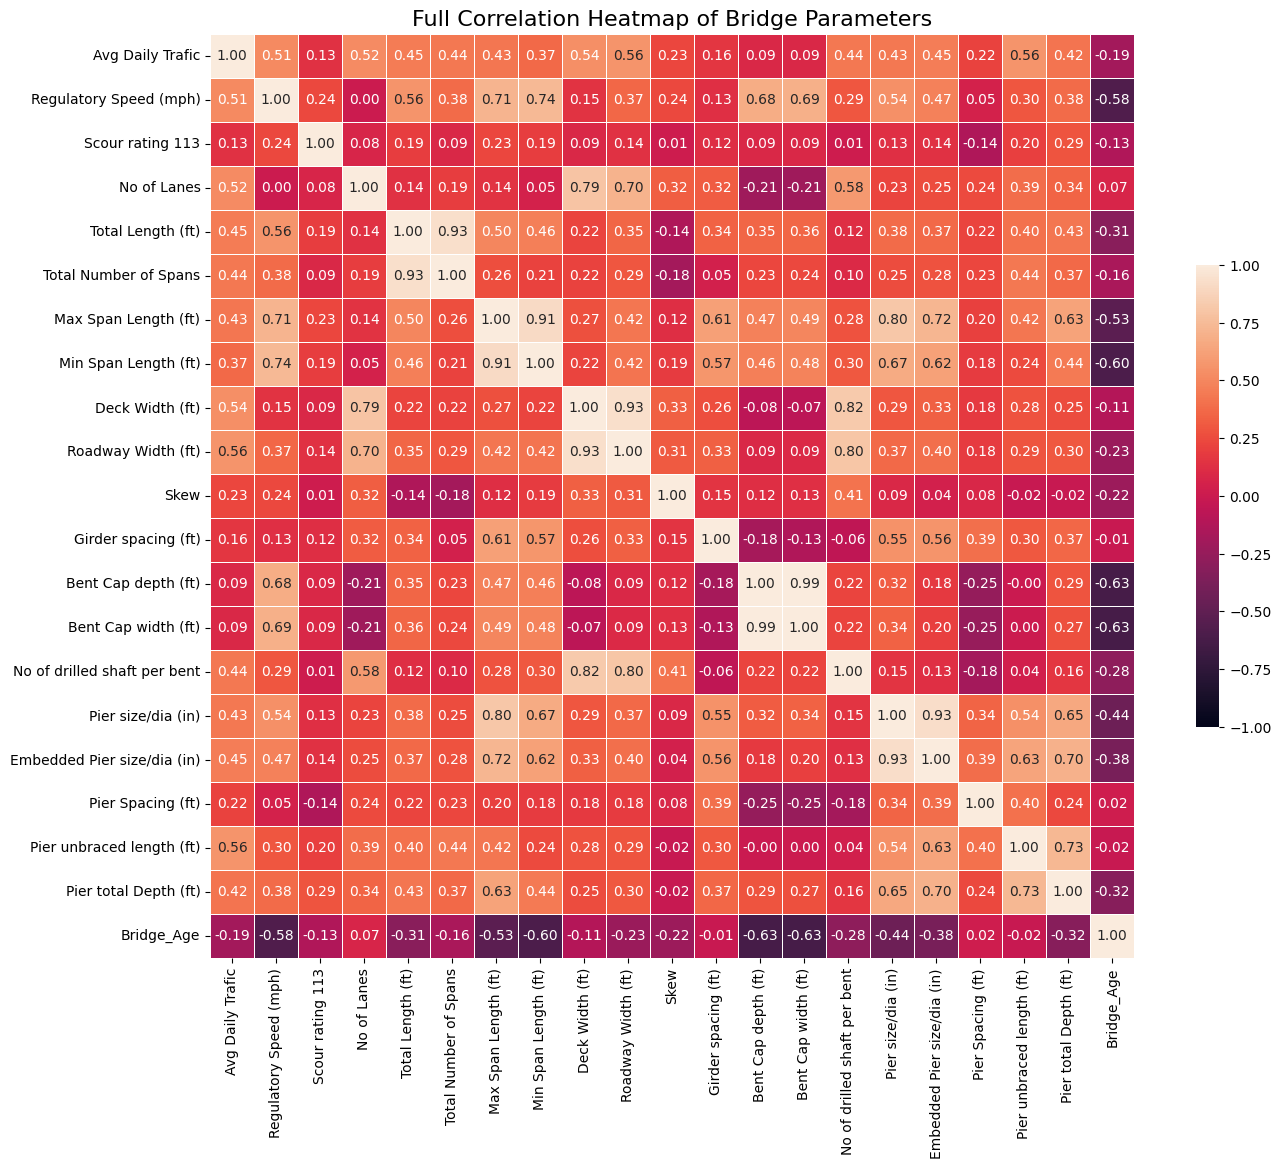

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. DATA CLEANING (Same as before)
cols_to_drop = ['SI', 'Asset Name', 'NBI 007: Facility Carried by Structure', 'NBI 006: Feature Intersected']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

numeric_cols = [
    'Avg Daily Trafic', 'Regulatory Speed (mph)', 'Scour rating 113',
    'No of Lanes', 'Total Length (ft)', 'Total Number of Spans',
    'Max Span Length (ft)', 'Min Span Length (ft)', 'Deck Width (ft)',
    'Roadway Width (ft)', 'Skew', 'Girder spacing (ft)',
    'Bent Cap depth (ft)', 'Bent Cap width (ft)',
    'No of drilled shaft per bent', 'Pier size/dia (in)',
    'Embedded Pier size/dia (in)', 'Pier Spacing (ft)',
    'Pier unbraced length (ft)', 'Pier total Depth (ft)', 'Years Build'
]

for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

if 'Years Build' in df_clean.columns:
    df_clean['Bridge_Age'] = 2025 - df_clean['Years Build']
    df_clean = df_clean.drop(columns=['Years Build'])

df_numeric = df_clean.select_dtypes(include=[np.number])

# 3. FULL SQUARE HEATMAP
plt.figure(figsize=(16, 12))

# Calculate correlation matrix
corr_matrix = df_numeric.corr()

# Create heatmap WITHOUT the mask
sns.heatmap(corr_matrix,
            annot=True,         # Show numbers
            fmt=".2f",          # 2 decimal places
            cmap='rocket',    # Color scheme
            vmax=1, vmin=-1,    # Scale
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .5})

plt.title('Full Correlation Heatmap of Bridge Parameters', fontsize=16)
plt.show()

Running Grid Search... (This might take a minute)
Best Parameters: {'model__depth': 4, 'model__learning_rate': 0.1}
Best R2 Score: 0.6956


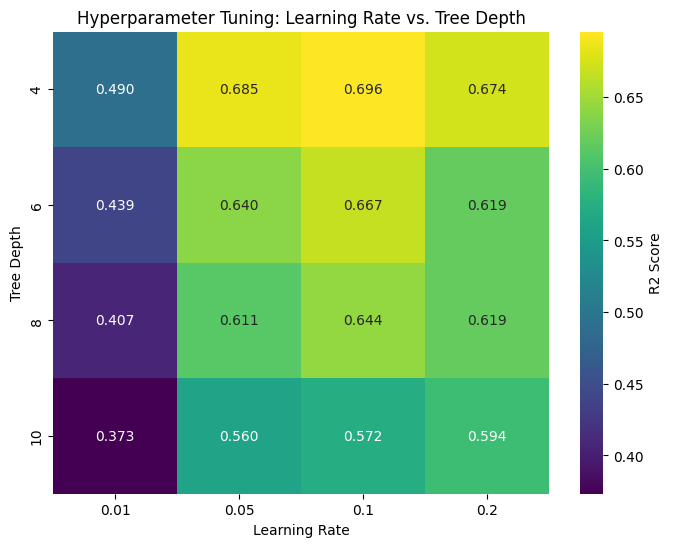

Generating Validation Curve...


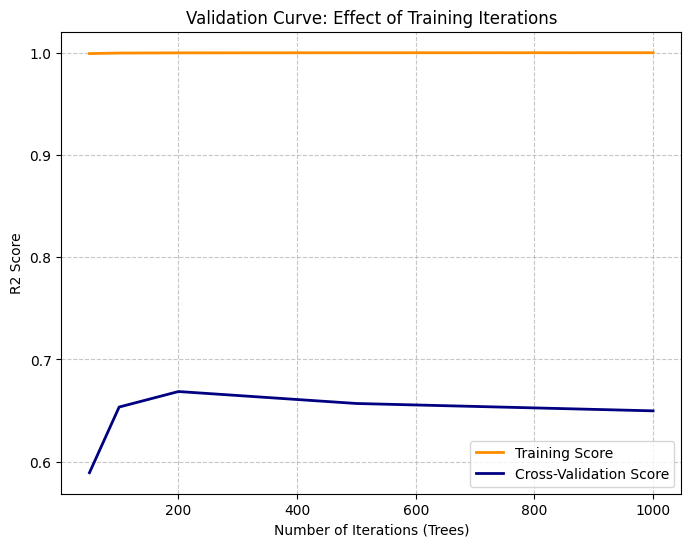

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV, validation_curve
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer



numeric_features = [
    'Avg Daily Trafic', 'Regulatory Speed (mph)', 'Scour rating 113',
    'No of Lanes', 'Total Length (ft)', 'Total Number of Spans',
    'Max Span Length (ft)', 'Min Span Length (ft)', 'Deck Width (ft)',
    'Roadway Width (ft)', 'Skew', 'Girder spacing (ft)',
    'Bent Cap depth (ft)', 'Bent Cap width (ft)',
    'No of drilled shaft per bent', 'Pier size/dia (in)',
    'Embedded Pier size/dia (in)', 'Pier Spacing (ft)',
    'Pier unbraced length (ft)'
]
categorical_features = ['Design Load', 'Girder Type', 'Rail Type', 'Pier Shape']

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in categorical_features:
    df[col] = df[col].astype(str)

df['Bridge_Age'] = 2025 - pd.to_numeric(df['Years Build'], errors='coerce')
numeric_features.append('Bridge_Age')

X = df[numeric_features + categorical_features]
y = df[target_col]

# 2. PREPROCESSING PIPELINE
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
    ])

# 3. HYPERPARAMETER TUNING (Grid Search)
# We test Learning Rate vs. Tree Depth
param_grid = {
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__depth': [4, 6, 8, 10]
}

pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', CatBoostRegressor(iterations=200, verbose=0, random_state=42))])

# Stratified Split for Validation
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running Grid Search... (This might take a minute)")
grid_search = GridSearchCV(pipeline, param_grid, cv=cv.split(X, y_binned), scoring='r2', n_jobs=-1)
grid_search.fit(X, y)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best R2 Score: {grid_search.best_score_:.4f}")

# 4. VISUALIZATION 1: TUNING HEATMAP
# Extract results
results_df = pd.DataFrame(grid_search.cv_results_)
pivot_table = results_df.pivot(index='param_model__depth', columns='param_model__learning_rate', values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap='viridis', cbar_kws={'label': 'R2 Score'})
plt.title('Hyperparameter Tuning: Learning Rate vs. Tree Depth')
plt.xlabel('Learning Rate')
plt.ylabel('Tree Depth')
plt.show()

# 5. VISUALIZATION 2: VALIDATION CURVE (Complexity Analysis)
# Checking effect of 'iterations' (How long to train?)
print("Generating Validation Curve...")
param_range = [50, 100, 200, 500, 1000]
train_scores, test_scores = validation_curve(
    pipeline, X, y, param_name="model__iterations", param_range=param_range,
    cv=cv.split(X, y_binned), scoring="r2", n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(param_range, train_mean, label="Training Score", color="darkorange", lw=2)
plt.plot(param_range, test_mean, label="Cross-Validation Score", color="navy", lw=2)

plt.title("Validation Curve: Effect of Training Iterations")
plt.xlabel("Number of Iterations (Trees)")
plt.ylabel("R2 Score")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Running 5-Fold Cross-Validation on Regression Models...
------------------------------------------------------------

--- Phase II: Regression Model Comparison (5-Fold CV) ---
            Model  Avg R2 Score  Avg MAE (ft)  Avg RMSE (ft)  R2 Std Dev
    Random Forest      0.403530      9.397782      13.152666    0.268147
     SVR (Radial)      0.370041      9.181093      12.724808    0.427586
Gradient Boosting      0.328368      9.746718      13.572490    0.385607
          XGBoost      0.246101     10.018272      14.304535    0.438460


/tmp/ipython-input-3543006108.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='R2 Score', data=plot_data, palette='viridis')


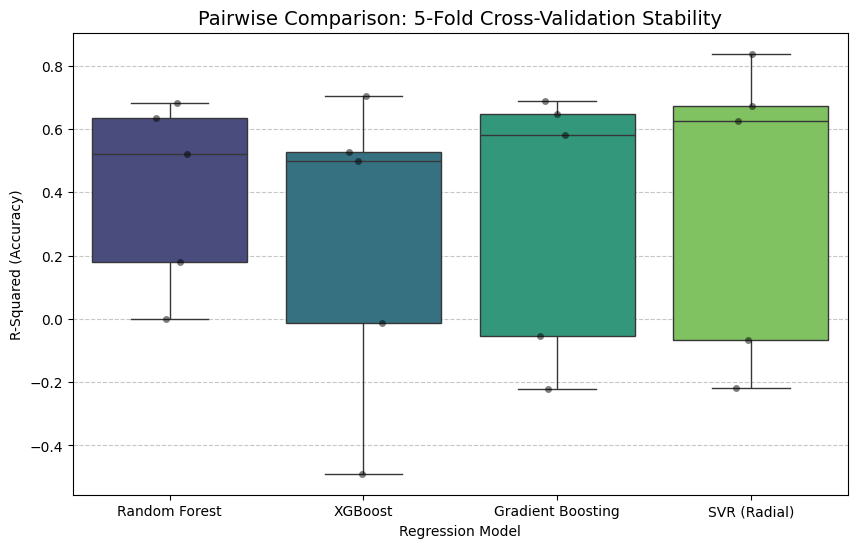


--- Pairwise R2 Difference Matrix (Row - Column) ---
Model             Random Forest SVR (Radial) Gradient Boosting   XGBoost
Model                                                                   
Random Forest               0.0     0.033489          0.075162  0.157429
SVR (Radial)          -0.033489          0.0          0.041673   0.12394
Gradient Boosting     -0.075162    -0.041673               0.0  0.082267
XGBoost               -0.157429     -0.12394         -0.082267       0.0


In [7]:
# Drop identification columns that are not useful for prediction
cols_to_drop = [
    'SI', 'Asset Name',
    'NBI 007: Facility Carried by Structure',
    'NBI 006: Feature Intersected'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

# List of Numeric Features (Inputs)
numeric_features = [
    'Avg Daily Trafic', 'Regulatory Speed (mph)', 'Scour rating 113',
    'No of Lanes', 'Total Length (ft)', 'Total Number of Spans',
    'Max Span Length (ft)', 'Min Span Length (ft)', 'Deck Width (ft)',
    'Roadway Width (ft)', 'Skew', 'Girder spacing (ft)',
    'Bent Cap depth (ft)', 'Bent Cap width (ft)',
    'No of drilled shaft per bent', 'Pier size/dia (in)',
    'Embedded Pier size/dia (in)', 'Pier Spacing (ft)',
    'Pier unbraced length (ft)'
]

# List of Categorical Features (Inputs)
categorical_features = ['Design Load', 'Girder Type', 'Rail Type', 'Pier Shape']

# 3. CLEANING & ENGINEERING
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert categorical features to string type to avoid mixed-type issues with OneHotEncoder
for col in categorical_features:
    df[col] = df[col].astype(str)

df['Bridge_Age'] = 2025 - pd.to_numeric(df['Years Build'], errors='coerce')
numeric_features.append('Bridge_Age')

X = df[numeric_features + categorical_features]
y = df[target_col]

# 4. PREPROCESSING PIPELINE
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

# 5. DEFINE MODELS FOR COMPARISON
# We compare regressor versions of the classifiers used in Phase I
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "SVR (Radial)": SVR(kernel='rbf', C=100, epsilon=0.1) # Tuned slightly for regression
}

# 6. RUN 5-FOLD CROSS-VALIDATION
# We use KFold (not Stratified, because target is continuous number)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results_data = []
model_scores_raw = {} # To store raw arrays for boxplot

print("Running 5-Fold Cross-Validation on Regression Models...")
print("-" * 60)

for name, model in models.items():
    # Create Full Pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Run CV
    # neg_mean_absolute_error is used because sklearn tries to maximize score (so errors are negative)
    cv_results = cross_validate(pipeline, X, y, cv=cv,
                                scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'])

    # Extract Scores
    r2_scores = cv_results['test_r2']
    mae_scores = -cv_results['test_neg_mean_absolute_error'] # Flip sign back to positive
    rmse_scores = -cv_results['test_neg_root_mean_squared_error']

    model_scores_raw[name] = r2_scores # Store for plotting

    results_data.append({
        "Model": name,
        "Avg R2 Score": r2_scores.mean(),
        "Avg MAE (ft)": mae_scores.mean(),
        "Avg RMSE (ft)": rmse_scores.mean(),
        "R2 Std Dev": r2_scores.std() # Stability metric
    })

# 7. GENERATE SUMMARY TABLE
results_df = pd.DataFrame(results_data).sort_values(by='Avg R2 Score', ascending=False)
print("\n--- Phase II: Regression Model Comparison (5-Fold CV) ---")
print(results_df.to_string(index=False))

# 8. PAIRWISE COMPARISON VISUALIZATION
plt.figure(figsize=(10, 6))

# Prepare data for Seaborn Boxplot
plot_data = pd.DataFrame(model_scores_raw).melt(var_name='Model', value_name='R2 Score')

# Plot
sns.boxplot(x='Model', y='R2 Score', data=plot_data, palette='viridis')
sns.stripplot(x='Model', y='R2 Score', data=plot_data, color='black', alpha=0.5, jitter=True) # Show individual folds

plt.title('Pairwise Comparison: 5-Fold Cross-Validation Stability', fontsize=14)
plt.ylabel('R-Squared (Accuracy)')
plt.xlabel('Regression Model')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# 9. STATISTICAL PAIRWISE DIFFERENCE (Optional Text Matrix)
# Shows the difference in average R2 between models
print("\n--- Pairwise R2 Difference Matrix (Row - Column) ---")
r2_means = results_df.set_index('Model')['Avg R2 Score']
diff_matrix = pd.DataFrame(index=r2_means.index, columns=r2_means.index)

for row in diff_matrix.index:
    for col in diff_matrix.columns:
        diff_matrix.loc[row, col] = r2_means[row] - r2_means[col]

print(diff_matrix)

##Random Forest using K-fold

In [8]:
# Feature Groups
numeric_features = [
    'Avg Daily Trafic', 'Regulatory Speed (mph)', 'Scour rating 113',
    'No of Lanes', 'Total Length (ft)', 'Total Number of Spans',
    'Max Span Length (ft)', 'Min Span Length (ft)', 'Deck Width (ft)',
    'Roadway Width (ft)', 'Skew', 'Girder spacing (ft)',
    'Bent Cap depth (ft)', 'Bent Cap width (ft)',
    'No of drilled shaft per bent', 'Pier size/dia (in)',
    'Embedded Pier size/dia (in)', 'Pier Spacing (ft)',
    'Pier unbraced length (ft)'
]
categorical_features = ['Design Load', 'Girder Type', 'Rail Type', 'Pier Shape']

# 3. CLEANING & ENGINEERING
for col in numeric_features:
    # Convert 'U' and text to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert categorical features to string type to avoid mixed-type issues with OneHotEncoder
for col in categorical_features:
    df[col] = df[col].astype(str)

# Create Bridge Age
df['Bridge_Age'] = 2025 - pd.to_numeric(df['Years Build'], errors='coerce')
numeric_features.append('Bridge_Age')

X = df[numeric_features + categorical_features]
y = df[target_col]

# 4. PREPROCESSING PIPELINE
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

# 5. CONFIGURE MODEL AND CROSS-VALIDATION
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', rf_model)])

# K-Fold Setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 6. RUN VALIDATION
print("Running Random Forest 5-Fold Cross-Validation...")
print("-" * 50)

# We get the R2 score for every fold
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='r2')

# 7. OUTPUT RESULTS
for i, score in enumerate(scores):
    print(f"Fold {i+1} Accuracy (R2): {score:.4f}")

print("-" * 50)
print(f"Average Accuracy:      {scores.mean():.4f}")
print(f"Standard Deviation:    {scores.std():.4f}")

Running Random Forest 5-Fold Cross-Validation...
--------------------------------------------------
Fold 1 Accuracy (R2): 0.6356
Fold 2 Accuracy (R2): -0.0017
Fold 3 Accuracy (R2): 0.6815
Fold 4 Accuracy (R2): 0.5225
Fold 5 Accuracy (R2): 0.1797
--------------------------------------------------
Average Accuracy:      0.4035
Standard Deviation:    0.2681


##Random Forest using Stratified K-fold Setup

In [9]:
# 5. STRATIFIED K-FOLD SETUP
# Since 'Depth' is continuous, we create temporary "bins" to simulate categories
# This ensures every fold has a mix of Shallow, Medium, and Deep bridges
num_bins = 5
y_binned = pd.qcut(y, q=num_bins, labels=False, duplicates='drop')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 6. RUN VALIDATION
print("Running Stratified Random Forest 5-Fold Cross-Validation...")
print("-" * 50)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', rf_model)])

scores = []
fold = 1

# We have to loop manually because cross_val_score doesn't accept the 'y_binned' for splitting
for train_index, test_index in skf.split(X, y_binned):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test) # This calculates R2
    scores.append(score)

    print(f"Fold {fold} Accuracy (R2): {score:.4f}")
    fold += 1

scores = np.array(scores)

print("-" * 50)
print(f"Average Accuracy:      {scores.mean():.4f}")
print(f"Standard Deviation:    {scores.std():.4f}")

Running Stratified Random Forest 5-Fold Cross-Validation...
--------------------------------------------------
Fold 1 Accuracy (R2): 0.6317
Fold 2 Accuracy (R2): 0.7234
Fold 3 Accuracy (R2): 0.3726
Fold 4 Accuracy (R2): 0.6176
Fold 5 Accuracy (R2): 0.6175
--------------------------------------------------
Average Accuracy:      0.5926
Standard Deviation:    0.1169


##Linear Regression

In [10]:
from sklearn.linear_model import LinearRegression

y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

scores = []
print(f"--- Linear Regression 5-Fold CV ---")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y_binned)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"Fold {i+1} R2: {score:.4f}")

print(f"\nAverage R2: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- Linear Regression 5-Fold CV ---
Fold 1 R2: -2.2087
Fold 2 R2: -1.7901
Fold 3 R2: -16.7627
Fold 4 R2: -0.8705
Fold 5 R2: -3.4532

Average R2: -5.0170
Standard Deviation: 5.9313


##Ridge Regression

In [11]:
from sklearn.linear_model import Ridge

y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ridge Regression (Regularized Linear Regression)
model = Ridge(random_state=42)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

scores = []
print(f"--- Ridge Regression 5-Fold CV ---")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y_binned)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"Fold {i+1} R2: {score:.4f}")

print(f"\nAverage R2: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- Ridge Regression 5-Fold CV ---
Fold 1 R2: 0.5857
Fold 2 R2: 0.6181
Fold 3 R2: 0.4591
Fold 4 R2: 0.6449
Fold 5 R2: 0.5472

Average R2: 0.5710
Standard Deviation: 0.0648


##SVR



In [12]:
from sklearn.svm import SVR

model = SVR(kernel='rbf', C=100, epsilon=0.1)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

scores = []
print(f"--- SVR (SVM) 5-Fold CV ---")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y_binned)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"Fold {i+1} R2: {score:.4f}")

print(f"\nAverage R2: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- SVR (SVM) 5-Fold CV ---
Fold 1 R2: 0.6801
Fold 2 R2: 0.8495
Fold 3 R2: 0.4789
Fold 4 R2: 0.5034
Fold 5 R2: 0.6018

Average R2: 0.6227
Standard Deviation: 0.1342


##Gradient Boosting

In [13]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=100, random_state=42)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

scores = []
print(f"--- Gradient Boosting 5-Fold CV ---")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y_binned)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"Fold {i+1} R2: {score:.4f}")

print(f"\nAverage R2: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- Gradient Boosting 5-Fold CV ---
Fold 1 R2: 0.6632
Fold 2 R2: 0.7406
Fold 3 R2: 0.1571
Fold 4 R2: 0.5182
Fold 5 R2: 0.7131

Average R2: 0.5584
Standard Deviation: 0.2148


##XGBoost

In [14]:
from xgboost import XGBRegressor

y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost Regressor
# n_jobs=-1 uses all processors
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

scores = []
print(f"--- XGBoost 5-Fold CV ---")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y_binned)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"Fold {i+1} R2: {score:.4f}")

print(f"\nAverage R2: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- XGBoost 5-Fold CV ---
Fold 1 R2: 0.6604
Fold 2 R2: 0.5797
Fold 3 R2: -0.1608
Fold 4 R2: 0.3557
Fold 5 R2: 0.3813

Average R2: 0.3632
Standard Deviation: 0.2864


##CatBoost

In [15]:
!pip install catboost
from catboost import CatBoostRegressor

y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CatBoost Regressor
# verbose=0 silences the training output for each tree
model = CatBoostRegressor(iterations=100, learning_rate=0.1, random_state=42, verbose=0)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

scores = []
print(f"--- CatBoost 5-Fold CV ---")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y_binned)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"Fold {i+1} R2: {score:.4f}")

print(f"\nAverage R2: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- CatBoost 5-Fold CV ---
Fold 1 R2: 0.6477
Fold 2 R2: 0.7576
Fold 3 R2: 0.5002
Fold 4 R2: 0.6656
Fold 5 R2: 0.7080

Average R2: 0.6558
Standard Deviation: 0.0866


##ANN

In [16]:
from sklearn.neural_network import MLPRegressor

# STRATIFIED CV
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# MLP Configuration: 2 hidden layers with 100 and 50 neurons
model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=3000, random_state=42)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

scores = []
print(f"--- ANN (MLP) 5-Fold CV ---")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y_binned)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"Fold {i+1} R2: {score:.4f}")

print(f"\nAverage R2: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- ANN (MLP) 5-Fold CV ---
Fold 1 R2: 0.6986
Fold 2 R2: 0.7066
Fold 3 R2: 0.5551
Fold 4 R2: 0.5216
Fold 5 R2: 0.5782

Average R2: 0.6120
Standard Deviation: 0.0762


##LightGBM Regressor

In [17]:
import lightgbm as lgb
# STRATIFIED CV
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

scores = []
print(f"--- LightGBM 5-Fold CV ---")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y_binned)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"Fold {i+1} R2: {score:.4f}")

print(f"\nAverage R2: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- LightGBM 5-Fold CV ---
Fold 1 R2: 0.3808


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 2 R2: 0.5380
Fold 3 R2: 0.5257
Fold 4 R2: 0.5340
Fold 5 R2: 0.5454

Average R2: 0.5048
Standard Deviation: 0.0623


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


##KNN

In [18]:
from sklearn.neighbors import KNeighborsRegressor

# 3. STRATIFIED CV
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = KNeighborsRegressor(n_neighbors=5)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

scores = []
print(f"--- KNN 5-Fold CV ---")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y_binned)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"Fold {i+1} R2: {score:.4f}")

print(f"\nAverage R2: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- KNN 5-Fold CV ---
Fold 1 R2: 0.5699
Fold 2 R2: 0.7985
Fold 3 R2: 0.3824
Fold 4 R2: -0.0195
Fold 5 R2: 0.6957

Average R2: 0.4854
Standard Deviation: 0.2881


In [19]:
numeric_features = [
    'Avg Daily Trafic', 'Regulatory Speed (mph)', 'Scour rating 113',
    'No of Lanes', 'Total Length (ft)', 'Total Number of Spans',
    'Max Span Length (ft)', 'Min Span Length (ft)', 'Deck Width (ft)',
    'Roadway Width (ft)', 'Skew', 'Girder spacing (ft)',
    'Bent Cap depth (ft)', 'Bent Cap width (ft)',
    'No of drilled shaft per bent', 'Pier size/dia (in)',
    'Embedded Pier size/dia (in)', 'Pier Spacing (ft)',
    'Pier unbraced length (ft)'
]
categorical_features = ['Design Load', 'Girder Type', 'Rail Type', 'Pier Shape']

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in categorical_features:
    df[col] = df[col].astype(str)

df['Bridge_Age'] = 2025 - pd.to_numeric(df['Years Build'], errors='coerce')
numeric_features.append('Bridge_Age')

X = df[numeric_features + categorical_features]
y = df[target_col]

# 2. PIPELINE PREPROCESSING
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
    ])

# 3. DEFINE OPTIMIZED STACKING ENSEMBLE
# We use the Top 3 Models from your leaderboard
estimators = [
    ('cat', CatBoostRegressor(iterations=100, learning_rate=0.1, random_state=42, verbose=0)),
    ('svr', SVR(kernel='rbf', C=100, epsilon=0.1)),
    ('ann', MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42))
]

# The "Final Estimator" (Meta-Model) learns how to combine the predictions
# Ridge is usually best for this to avoid overfitting the meta-learner
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge()
)

pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', stacking_model)])

# 4. STRATIFIED CV
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
print(f"--- Optimized Stacking (CatBoost + SVR + ANN) 5-Fold CV ---")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y_binned)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"Fold {i+1} R2: {score:.4f}")

print(f"\nAverage R2: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- Optimized Stacking (CatBoost + SVR + ANN) 5-Fold CV ---
Fold 1 R2: 0.7783
Fold 2 R2: 0.7202
Fold 3 R2: 0.1065


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 4 R2: 0.6047


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 5 R2: 0.5441

Average R2: 0.5508
Standard Deviation: 0.2370


--- Final Champion Model Metrics ---
R2 Score: 0.6618
MAE:      7.80 ft
RMSE:     11.49 ft


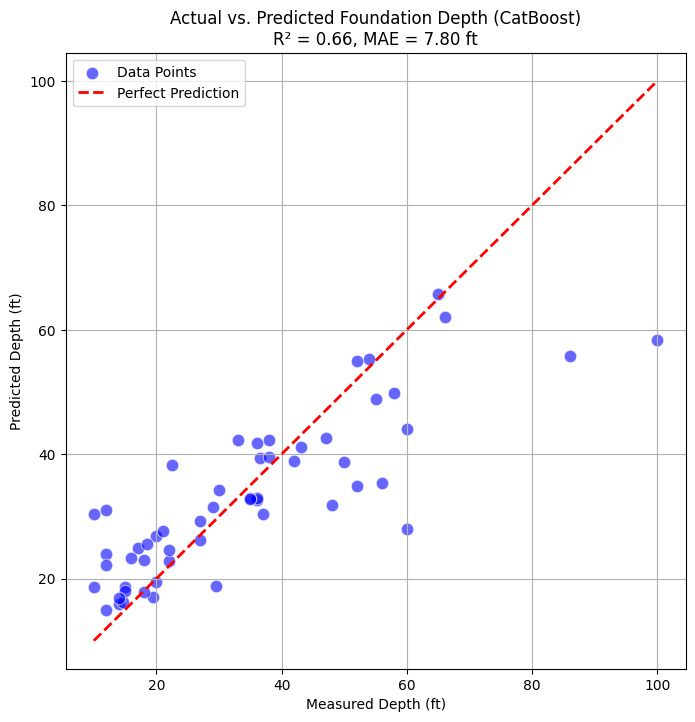

/tmp/ipython-input-1941134568.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_df, palette='plasma')


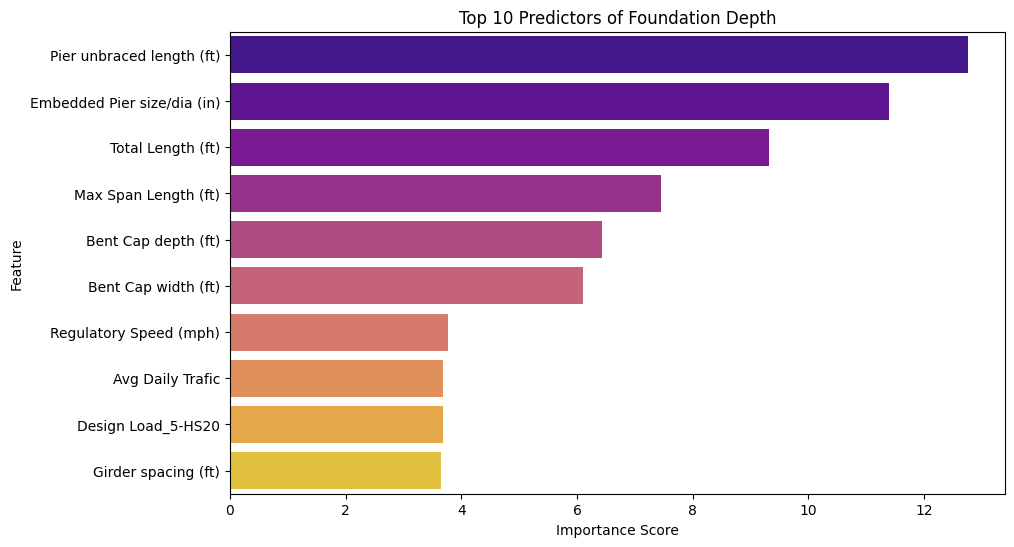

In [20]:

numeric_features = [
    'Avg Daily Trafic', 'Regulatory Speed (mph)', 'Scour rating 113',
    'No of Lanes', 'Total Length (ft)', 'Total Number of Spans',
    'Max Span Length (ft)', 'Min Span Length (ft)', 'Deck Width (ft)',
    'Roadway Width (ft)', 'Skew', 'Girder spacing (ft)',
    'Bent Cap depth (ft)', 'Bent Cap width (ft)',
    'No of drilled shaft per bent', 'Pier size/dia (in)',
    'Embedded Pier size/dia (in)', 'Pier Spacing (ft)',
    'Pier unbraced length (ft)'
]
categorical_features = ['Design Load', 'Girder Type', 'Rail Type', 'Pier Shape']

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in categorical_features:
    df[col] = df[col].astype(str)

df['Bridge_Age'] = 2025 - pd.to_numeric(df['Years Build'], errors='coerce')
numeric_features.append('Bridge_Age')

X = df[numeric_features + categorical_features]
y = df[target_col]

# 2. PREPROCESSING
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)
    ])

# 3. CONFIGURE CHAMPION MODEL
model = CatBoostRegressor(iterations=100, learning_rate=0.1, random_state=42, verbose=0)
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

# 4. GENERATE PREDICTIONS (Cross-Validated) - Modified to handle StratifiedKFold with continuous target
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = np.zeros(len(y)) # Initialize array to store predictions

for train_index, test_index in skf.split(X, y_binned):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    pipeline.fit(X_train, y_train)
    y_pred[test_index] = pipeline.predict(X_test)

# 5. CALCULATE FINAL METRICS
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"--- Final Champion Model Metrics ---")
print(f"R2 Score: {r2:.4f}")
print(f"MAE:      {mae:.2f} ft")
print(f"RMSE:     {rmse:.2f} ft")

# 6. PLOT 1: ACTUAL VS PREDICTED
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y, y=y_pred, color='blue', alpha=0.6, s=80, label='Data Points')
# Perfect prediction line
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title(f'Actual vs. Predicted Foundation Depth (CatBoost)\nR² = {r2:.2f}, MAE = {mae:.2f} ft')
plt.xlabel('Measured Depth (ft)')
plt.ylabel('Predicted Depth (ft)')
plt.legend()
plt.grid(True)
plt.show()

# 7. PLOT 2: FEATURE IMPORTANCE
# We need to fit the model once on the whole dataset to get importances
pipeline.fit(X, y)

# Extract feature names
# Numeric are easy
feat_names = numeric_features.copy()
# Categorical names from OneHotEncoder
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat']['encoder']
feat_names.extend(cat_encoder.get_feature_names_out(categorical_features))

# Extract importance from CatBoost
importances = pipeline.named_steps['model'].feature_importances_

# Create DataFrame
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='plasma')
plt.title('Top 10 Predictors of Foundation Depth')
plt.xlabel('Importance Score')
plt.show()

In [21]:
from lightgbm import LGBMRegressor

#. DEFINE ALL 10 MODELS
models = {
    "CatBoost": CatBoostRegressor(iterations=100, learning_rate=0.1, random_state=42, verbose=0),
    "SVR (SVM)": SVR(kernel='rbf', C=100, epsilon=0.1),
    "ANN (MLP)": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Ridge Regression": Ridge(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, verbose=-1, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# 4. RUN COMPARISON
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_data = []

print(f"{'Model':<20} | {'R2':<8} | {'MAE':<8} | {'RMSE':<8}")
print("-" * 55)

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    fold_r2 = []
    fold_mae = []
    fold_rmse = []

    for train_idx, test_idx in skf.split(X, y_binned):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        fold_r2.append(r2_score(y_test, y_pred))
        fold_mae.append(mean_absolute_error(y_test, y_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))

    # Calculate Averages
    avg_r2 = np.mean(fold_r2)
    avg_mae = np.mean(fold_mae)
    avg_rmse = np.mean(fold_rmse)

    results_data.append({
        "Model": name,
        "K": 5,
        "r (Correlation)": np.sqrt(abs(avg_r2)), # Approximation of r
        "Accuracy (R2)": avg_r2,
        "MAE (Error ft)": avg_mae,
        "RMSE (Error ft)": avg_rmse,
        "Sensitivity": "N/A",
        "Specificity": "N/A",
        "Precision": "N/A",
        "F1 Score": "N/A"
    })

    print(f"{name:<20} | {avg_r2:<8.4f} | {avg_mae:<8.2f} | {avg_rmse:<8.2f}")

# 5. SAVE FINAL TABLE
results_df = pd.DataFrame(results_data)
print("\n--- Final Metric Table ---")
print(results_df[['Model', 'K', 'Accuracy (R2)', 'MAE (Error ft)', 'RMSE (Error ft)']])

Model                | R2       | MAE      | RMSE    
-------------------------------------------------------
CatBoost             | 0.6558   | 7.80     | 11.31   
SVR (SVM)            | 0.6227   | 8.47     | 11.67   


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


ANN (MLP)            | 0.6120   | 8.98     | 11.98   
Random Forest        | 0.5926   | 8.35     | 12.26   
Ridge Regression     | 0.5710   | 9.71     | 12.73   
Gradient Boosting    | 0.5584   | 8.62     | 12.40   
LightGBM             | 0.5048   | 10.02    | 13.77   


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


KNN                  | 0.4854   | 9.70     | 13.19   
XGBoost              | 0.3863   | 10.08    | 14.62   
Linear Regression    | -5.0170  | 31.74    | 42.91   

--- Final Metric Table ---
               Model  K  Accuracy (R2)  MAE (Error ft)  RMSE (Error ft)
0           CatBoost  5       0.655820        7.799487        11.311347
1          SVR (SVM)  5       0.622731        8.472194        11.667283
2          ANN (MLP)  5       0.611997        8.983423        11.978392
3      Random Forest  5       0.592560        8.348255        12.262445
4   Ridge Regression  5       0.571024        9.706738        12.730616
5  Gradient Boosting  5       0.558450        8.623473        12.402324
6           LightGBM  5       0.504770       10.023403        13.765915
7                KNN  5       0.485392        9.700727        13.191749
8            XGBoost  5       0.386250       10.075285        14.619638
9  Linear Regression  5      -5.017041       31.742011        42.907659


In [22]:
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, confusion_matrix

# 3. DEFINE ALL 10 MODELS
models = {
    "CatBoost": CatBoostRegressor(iterations=100, learning_rate=0.1, random_state=42, verbose=0),
    "SVR (SVM)": SVR(kernel='rbf', C=100, epsilon=0.1),
    "ANN (MLP)": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Ridge Regression": Ridge(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, verbose=-1, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# 4. RUN COMPARISON
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
THRESHOLD_DEPTH = 20.0 # ft (Threshold to derive binary class from continuous depth)

results_data = []

print(f"{'Model':<20} | {'R2':<8} | {'MAE':<8} | {'Acc (Class)':<12}")
print("-" * 60)

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    # Storage for folds
    metrics = {
        'r': [], 'Accuracy': [], 'Sensitivity': [], 'Specificity': [],
        'Balanced Accuracy': [], 'Precision': [], 'Recall': [], 'F1 score': [],
        'R2': [], 'MAE': [], 'RMSE': []
    }

    for train_idx, test_idx in skf.split(X, y_binned):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        # --- Regression Metrics ---
        metrics['R2'].append(r2_score(y_test, y_pred))
        metrics['MAE'].append(mean_absolute_error(y_test, y_pred))
        metrics['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred)))

        # Pearson correlation (handle potential constant output edge case)
        if np.std(y_pred) < 1e-9:
            metrics['r'].append(0.0)
        else:
            metrics['r'].append(pearsonr(y_test, y_pred)[0])

        # --- Derived Classification Metrics (Thresholding) ---
        # Convert continuous depth to binary class (Deep=1, Shallow=0)
        y_test_class = (y_test >= THRESHOLD_DEPTH).astype(int)
        y_pred_class = (y_pred >= THRESHOLD_DEPTH).astype(int)

        metrics['Accuracy'].append(accuracy_score(y_test_class, y_pred_class))
        metrics['Precision'].append(precision_score(y_test_class, y_pred_class, zero_division=0))
        metrics['Recall'].append(recall_score(y_test_class, y_pred_class, zero_division=0)) # Same as Sensitivity
        metrics['F1 score'].append(f1_score(y_test_class, y_pred_class, zero_division=0))
        metrics['Balanced Accuracy'].append(balanced_accuracy_score(y_test_class, y_pred_class))

        # Specificity = TN / (TN + FP)
        tn, fp, fn, tp = confusion_matrix(y_test_class, y_pred_class, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        metrics['Specificity'].append(specificity)
        metrics['Sensitivity'].append(tp / (tp + fn) if (tp + fn) > 0 else 0)

    # Average over folds
    row = {
        "Model": name,
        "K": 5,
        "r": np.mean(metrics['r']),
        "Accuracy": np.mean(metrics['Accuracy']),
        "Sensitivity": np.mean(metrics['Sensitivity']),
        "Specificity": np.mean(metrics['Specificity']),
        "Balanced Accuracy": np.mean(metrics['Balanced Accuracy']),
        "Precision": np.mean(metrics['Precision']),
        "Recall": np.mean(metrics['Recall']),
        "F1 score": np.mean(metrics['F1 score']),
        # Adding Regression metrics for completeness
        "R2": np.mean(metrics['R2']),
        "MAE": np.mean(metrics['MAE'])
    }

    results_data.append(row)
    print(f"{name:<20} | {row['R2']:<8.4f} | {row['MAE']:<8.2f} | {row['Accuracy']:<12.4f}")

# 5. SAVE FINAL TABLE
results_df = pd.DataFrame(results_data)
# Reorder to match user request + useful regression metrics
cols = ['Model', 'K', 'r', 'Accuracy', 'Sensitivity', 'Specificity', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 score', 'R2', 'MAE']
print("\n--- Final Metric Table ---")
print(results_df[cols].to_string(index=False))

Model                | R2       | MAE      | Acc (Class) 
------------------------------------------------------------
CatBoost             | 0.6558   | 7.80     | 0.8182      
SVR (SVM)            | 0.6227   | 8.47     | 0.8182      


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


ANN (MLP)            | 0.6120   | 8.98     | 0.7818      
Random Forest        | 0.5926   | 8.35     | 0.8727      
Ridge Regression     | 0.5710   | 9.71     | 0.8364      
Gradient Boosting    | 0.5584   | 8.62     | 0.7455      
LightGBM             | 0.5048   | 10.02    | 0.8000      


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


KNN                  | 0.4854   | 9.70     | 0.8182      
XGBoost              | 0.3863   | 10.08    | 0.8000      
Linear Regression    | -5.0170  | 31.74    | 0.5455      

--- Final Metric Table ---
            Model  K        r  Accuracy  Sensitivity  Specificity  Balanced Accuracy  Precision   Recall  F1 score        R2       MAE
         CatBoost  5 0.856109  0.818182     0.950000     0.550000           0.750000   0.832828 0.950000  0.881928  0.655820  7.799487
        SVR (SVM)  5 0.837881  0.818182     0.950000     0.550000           0.750000   0.840051 0.950000  0.879664  0.622731  8.472194
        ANN (MLP)  5 0.814422  0.781818     0.875000     0.583333           0.729167   0.828968 0.875000  0.846373  0.611997  8.983423
    Random Forest  5 0.787106  0.872727     1.000000     0.583333           0.791667   0.846111 1.000000  0.915915  0.592560  8.348255
 Ridge Regression  5 0.817353  0.836364     0.950000     0.583333           0.766667   0.839762 0.950000  0.887680  0.57102

/tmp/ipython-input-3317854715.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy (R2)', data=df_plot, ax=ax1, palette='mako', alpha=0.8)
/tmp/ipython-input-3317854715.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


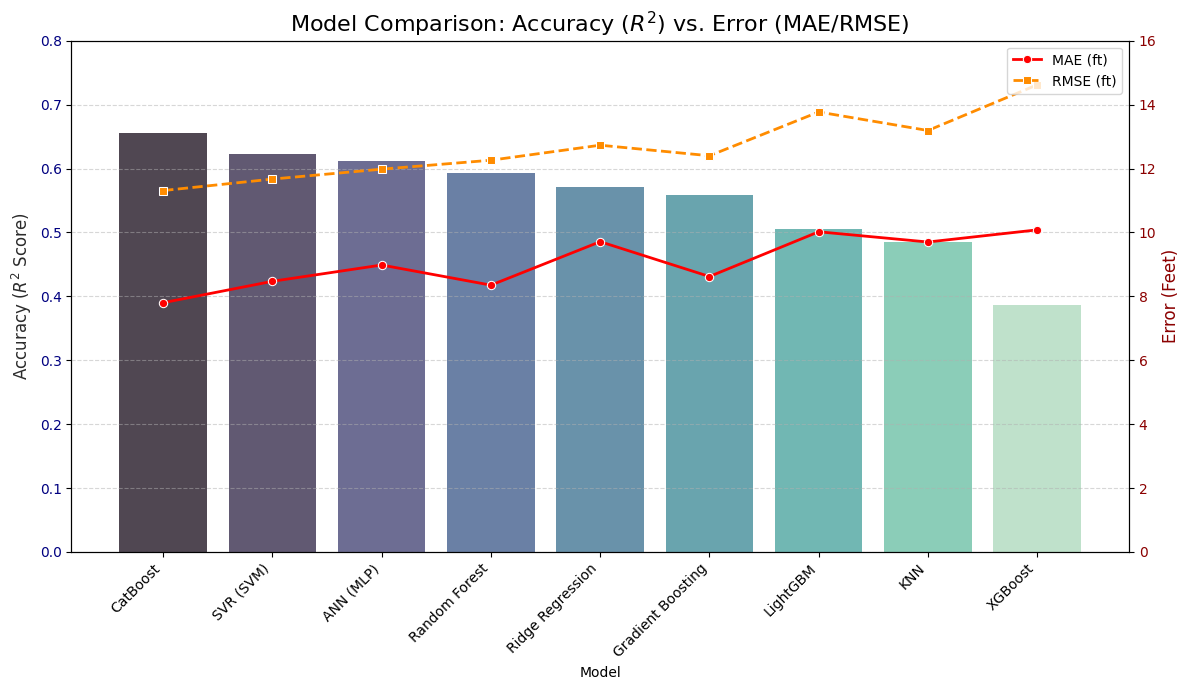

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CREATE DATAFRAME FROM YOUR TABLE
data = {
    'Model': [
        'CatBoost', 'SVR (SVM)', 'ANN (MLP)', 'Random Forest', 'Ridge Regression',
        'Gradient Boosting', 'LightGBM', 'KNN', 'XGBoost', 'Linear Regression'
    ],
    'Accuracy (R2)': [0.6558, 0.6227, 0.6120, 0.5926, 0.5710, 0.5585, 0.5048, 0.4854, 0.3863, -5.0170],
    'Avg Error (MAE)': [7.80, 8.47, 8.98, 8.35, 9.71, 8.62, 10.02, 9.70, 10.08, 31.74],
    'RMSE': [11.31, 11.67, 11.98, 12.26, 12.73, 12.40, 13.77, 13.19, 14.62, 42.91]
}

df_results = pd.DataFrame(data)

# 2. FILTER OUT 'LINEAR REGRESSION' FOR BETTER VISUALIZATION
# Linear Regression's negative R2 (-5.0) skews the chart too much.
# We remove it to focus on the competitive models.
df_plot = df_results[df_results['Model'] != 'Linear Regression'].copy()

# 3. SET UP THE PLOT
# We use a dual-axis plot: Bars for Accuracy (Left Axis), Line/Markers for Error (Right Axis)
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Accuracy (R2) as Bars
sns.barplot(x='Model', y='Accuracy (R2)', data=df_plot, ax=ax1, palette='mako', alpha=0.8)
ax1.set_ylabel('Accuracy ($R^2$ Score)', fontsize=12, color="#2B2B2B")
ax1.set_ylim(0, 0.8)
ax1.tick_params(axis='y', labelcolor='navy')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Create a second y-axis for Error Metrics
ax2 = ax1.twinx()

# Plot MAE and RMSE as Lines
sns.lineplot(x='Model', y='Avg Error (MAE)', data=df_plot, ax=ax2, color='red', marker='o', label='MAE (ft)', linewidth=2)
sns.lineplot(x='Model', y='RMSE', data=df_plot, ax=ax2, color='darkorange', marker='s', label='RMSE (ft)', linewidth=2, linestyle='--')

ax2.set_ylabel('Error (Feet)', fontsize=12, color='darkred')
ax2.set_ylim(0, 16) # Adjust based on your max error
ax2.tick_params(axis='y', labelcolor='darkred')

# Add Legend manually for lines
lines, labels = ax2.get_legend_handles_labels()
ax2.legend(lines, labels, loc='upper right')

# Final Touches
plt.title('Model Comparison: Accuracy ($R^2$) vs. Error (MAE/RMSE)', fontsize=16)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()